In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf # library 

print("Everything is ready!")

Everything is ready!


###  Download SPY data

In [2]:
TICKER = "SPY" # this is a short market symbol identifying an asset, the SPY is the ticker symbol for the SPDR S&P 500 ETF Trust
START_DATE = "2010-01-01"

# df is the name of the variable 
# we store the data in the df var

df = yf.download(
    TICKER,
    start=START_DATE, # we do not provide an end date so the function downloads through the latest available period
    interval="1d", # that means give me one row for every trading day, therefore each row contains one day's opening price, highest price, lowest price, closing price, trading volume 
    auto_adjust=True, # tells y finance to automaticaly adjust the open, high , low and close price columns for corporate actions such as stock splits and distributions
    progress=False,
    multi_level_index=False, # we currently have one ticker , so we dont need to download simultaneously more tickers.
)

# so for our project daily data are appropriate because we are trying to predict the next trading day's direction. 


## Dataset Columns

Each row represents one trading day for SPY.

- **Open:** The price of SPY when the stock market opened that day.

- **High:** The highest price reached by SPY during that trading day.

- **Low:** The lowest price reached by SPY during that trading day.

- **Close:** The price of SPY when the stock market closed that day.

- **Volume:** The total number of SPY shares traded during that day.

Because `auto_adjust=True` was used when downloading the data, the Open, High, Low, and Close prices are adjusted for events such as stock splits and dividend distributions.

In [3]:
df.head() # inspect the first five rows 

,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600
2010-01-05,84.802376,84.839693,84.220261,84.526247,111579900
2010-01-06,84.862068,85.071032,84.653104,84.720269,116074400
2010-01-07,85.220291,85.324773,84.466524,84.705341,131091100
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800


In [4]:
df.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2026-08-28,769.349976,775.299988,768.309998,771.760010,36744300
2026-08-31,767.049988,768.000000,764.719971,767.330017,38810800
2026-09-01,761.780029,764.669983,759.479980,762.010010,41126300
2026-09-02,765.159973,766.429993,761.729980,762.450012,29566200
2026-09-03,773.169983,774.030029,767.450012,767.900024,41442967


In [5]:
df.shape # (number of rows/trading days, number of columns)
print(f"Number of tradining days: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of tradining days: 4193
Number of columns: 5


In [6]:
# check the first and last dates
print(f"First date: {df.index.min()}")
print(f"Last date: {df.index.max()}")

First date: 2010-01-04 00:00:00
Last date: 2026-09-03 00:00:00


In [7]:
# check the data types
df.info()
# float64: numbers that can contain decimals
# int64: whole numbers
# DatetimeIndex: dates used to identify the rows

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4193 entries, 2010-01-04 to 2026-09-03
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4193 non-null   float64
 1   High    4193 non-null   float64
 2   Low     4193 non-null   float64
 3   Open    4193 non-null   float64
 4   Volume  4193 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 196.5 KB


In [8]:
# check for missing values
df.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [9]:
# remove incomplete rows
df = df.dropna().copy()

In [10]:
# view summary statistics
df.describe()

,Close,High,Low,Open,Volume
count,4193.000000,4193.000000,4193.000000,4193.000000,4.193000e+03
mean,285.456004,286.917373,283.752266,285.401896,1.075568e+08
std,175.938133,176.767876,174.956301,175.907151,6.735707e+07
min,76.950600,77.869189,76.144955,77.635779,2.027000e+07
25%,149.867401,150.588488,149.340863,149.932285,6.413040e+07
50%,235.766434,237.877709,234.312640,236.097434,8.774220e+07
75%,397.190002,399.444139,394.562695,397.115259,1.303717e+08
max,777.880005,779.369995,775.429993,778.539978,7.178287e+08


## Initial Data Inspection

The dataset was inspected to determine its size, date range, data types,
missing values, and summary statistics before conducting further analysis.


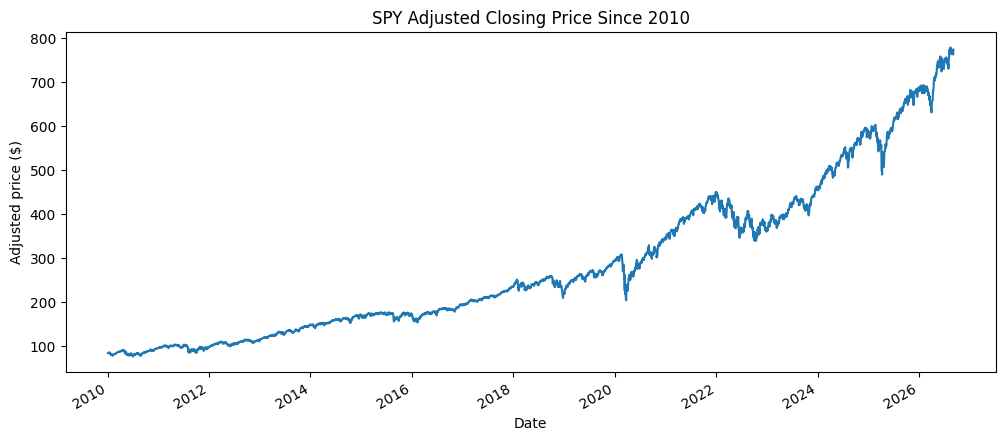

In [11]:
df["Close"].plot(
    figsize=(12,5),
    title="SPY Adjusted Closing Price Since 2010"
)
plt.xlabel("Date")
plt.ylabel("Adjusted price ($)")
plt.show()

## Daily Return

The daily return measures the percentage change between the opening and
closing price of the same trading day.

A positive value means that SPY closed above its opening price, while a
negative value means that it closed below its opening price.

In [12]:
# Will SPY go up or down during the next trading day?

df["daily_return"] = df["Close"] / df["Open"] - 1 # final price / initial price -1

In [13]:
df[["Open", "Close", "daily_return"]].head()

,Open,Close,daily_return
Date,,,
2010-01-04,83.862041,84.578491,0.008543
2010-01-05,84.526247,84.802376,0.003267
2010-01-06,84.720269,84.862068,0.001674
2010-01-07,84.705341,85.220291,0.006079
2010-01-08,84.996413,85.503899,0.005971


In [14]:
(df[["Open", "Close", "daily_return"]].head()
   .style.format({
       "Open": "{:.2f}",
       "Close": "{:.2f}",
       "daily_return": "{:.2%}"
   }))

,Open,Close,daily_return
Date,,,
2010-01-04 00:00:00,83.86,84.58,0.85%
2010-01-05 00:00:00,84.53,84.80,0.33%
2010-01-06 00:00:00,84.72,84.86,0.17%
2010-01-07 00:00:00,84.71,85.22,0.61%
2010-01-08 00:00:00,85.00,85.50,0.60%


In [15]:
# use information available through today to predict what happends tomorrow
# so we added a column where it has the daily return of the next day
df["next_day_return"] = df["daily_return"].shift(-1) # so the .shift(-1) moves tomorrow's daily return one row upward
df.head()

,Close,High,Low,Open,Volume,daily_return,next_day_return
Date,,,,,,,
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600,0.008543,0.003267
2010-01-05,84.802376,84.839693,84.220261,84.526247,111579900,0.003267,0.001674
2010-01-06,84.862068,85.071032,84.653104,84.720269,116074400,0.001674,0.006079
2010-01-07,85.220291,85.324773,84.466524,84.705341,131091100,0.006079,0.005971
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800,0.005971,-0.003041


In [16]:
df[["daily_return","next_day_return"]].head(10) # this does not mean tomorrow's return is known when aking the prediction
# we use it only to construct the historical answer that the model will learn from

,daily_return,next_day_return
Date,,
2010-01-04,0.008543,0.003267
2010-01-05,0.003267,0.001674
2010-01-06,0.001674,0.006079
2010-01-07,0.006079,0.005971
2010-01-08,0.005971,-0.003041
2010-01-11,-0.003041,-0.002720
2010-01-12,-0.002720,0.005880
2010-01-13,0.005880,0.003843
2010-01-14,0.003843,-0.009501


target = 1 → SPY went up during the next trading day

target = 0 → SPY went down or stayed unchanged

In [17]:
df["target"] = (df["next_day_return"] > 0 ).astype(int)
df["target"].head()

Date
2010-01-04    1
2010-01-05    1
2010-01-06    1
2010-01-07    1
2010-01-08    0
Name: target, dtype: int64

In [18]:
df[
    ["Open", "Close", "daily_return", "next_day_return", "target"]
].head(10)

,Open,Close,daily_return,next_day_return,target
Date,,,,,
2010-01-04,83.862041,84.578491,0.008543,0.003267,1
2010-01-05,84.526247,84.802376,0.003267,0.001674,1
2010-01-06,84.720269,84.862068,0.001674,0.006079,1
2010-01-07,84.705341,85.220291,0.006079,0.005971,1
2010-01-08,84.996413,85.503899,0.005971,-0.003041,0
2010-01-11,85.884519,85.623314,-0.003041,-0.002720,0
2010-01-12,85.056112,84.824760,-0.002720,0.005880,1
2010-01-13,85.041164,85.541191,0.005880,0.003843,1
2010-01-14,85.444200,85.772575,0.003843,-0.009501,0


### Remove the last incomplete row
The final date in the dataset has no next trading day inside our download data

Therefore, its next_day_return is missing

In [19]:
df[ [ "daily_return", "next_day_return", "target"]].tail()

,daily_return,next_day_return,target
Date,,,
2026-08-28,-0.003123,-0.000365,0
2026-08-31,-0.000365,-0.000302,0
2026-09-01,-0.000302,0.003554,1
2026-09-02,0.003554,0.006863,1
2026-09-03,0.006863,NaN,0


In [20]:
df = df.dropna(subset=["next_day_return"]).copy()
df.tail()

,Close,High,Low,Open,Volume,daily_return,next_day_return,target
Date,,,,,,,,
2026-08-27,771.099976,772.359985,767.159973,768.500000,34557100,0.003383,-0.003123,0
2026-08-28,769.349976,775.299988,768.309998,771.760010,36744300,-0.003123,-0.000365,0
2026-08-31,767.049988,768.000000,764.719971,767.330017,38810800,-0.000365,-0.000302,0
2026-09-01,761.780029,764.669983,759.479980,762.010010,41126300,-0.000302,0.003554,1
2026-09-02,765.159973,766.429993,761.729980,762.450012,29566200,0.003554,0.006863,1


In [21]:
df["target"].value_counts()

target
1    2280
0    1912
Name: count, dtype: int64

## Prediction Target

The target represents the direction of SPY during the following trading day:

- `1`: the next trading day closed above its opening price
- `0`: the next trading day closed at or below its opening price

The majority-class baseline represents the accuracy obtained by always
predicting the most common class. Future models should be compared against
this baseline rather than only against a 50% coin flip.

In [22]:
target_distribution = df["target"].value_counts(normalize=True).sort_index()
# value counts , how many zeros and ones there are , normalize = true means you get proportions instead of just counts and then sort index you just present first the 0 and then 1
print(f"Down or flat days: {target_distribution[0]:.2%}")
print(f"Up days: {target_distribution[1]:.2%}")

Down or flat days: 45.61%
Up days: 54.39%


In [23]:
target_distribution

target
0    0.456107
1    0.543893
Name: proportion, dtype: float64

In [24]:
majority_baseline = target_distribution.max()

print(f"Majority-class baseline accuracy: {majority_baseline:.2%}")

Majority-class baseline accuracy: 54.39%


### Input features
we create the input features that the model will use to predict tomorrow's direction
The target is the answer we want to predict, target = tomorrow up or down

The features are the information given to the model :
- today's return
- recent returns
- moving averages 
- volatility
- volume changes

All features must use information available today or earlier, never tomorrow's information


## Feature Engineering

Features are variables created from historical market data that may help the
model predict the next trading day's direction.

All features use only information available by the end of the current trading
day.

In [25]:
df.head()

,Close,High,Low,Open,Volume,daily_return,next_day_return,target
Date,,,,,,,,
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600,0.008543,0.003267,1
2010-01-05,84.802376,84.839693,84.220261,84.526247,111579900,0.003267,0.001674,1
2010-01-06,84.862068,85.071032,84.653104,84.720269,116074400,0.001674,0.006079,1
2010-01-07,85.220291,85.324773,84.466524,84.705341,131091100,0.006079,0.005971,1
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800,0.005971,-0.003041,0


In [26]:
# create past price returns
df["return_1d"] = df["Close"].pct_change(1) #compares today’s closing price with the previous trading day’s closing price
df["return_5d"] = df["Close"].pct_change(5) #compares today’s closing price with the closing price five trading days earlier
df["return_10d"] = df["Close"].pct_change(10)

In [27]:
df[
    ["Close", "return_1d", "return_5d", "return_10d"]
].head(12)

,Close,return_1d,return_5d,return_10d
Date,,,,
2010-01-04,84.578491,NaN,NaN,NaN
2010-01-05,84.802376,0.002647,NaN,NaN
2010-01-06,84.862068,0.000704,NaN,NaN
2010-01-07,85.220291,0.004221,NaN,NaN
2010-01-08,85.503899,0.003328,NaN,NaN
2010-01-11,85.623314,0.001397,0.012353,NaN
2010-01-12,84.824760,-0.009326,0.000264,NaN
2010-01-13,85.541191,0.008446,0.008003,NaN
2010-01-14,85.772575,0.002705,0.006481,NaN


In [28]:
# moving averages
# A moving average is the average closing price over a recent period 
df["moving_average_5d"] = df["Close"].rolling(window=5).mean() # for each date, calculate the average closing price over that date and the previous four trading days
df["moving_average_20d"] = df["Close"].rolling(window=20).mean()

In [29]:
# create features representing how far the current price is from each moving average:
df["distance_from_ma_5d"] = (
    df["Close"] / df["moving_average_5d"] - 1
)

df["distance_from_ma_20d"] = (
    df["Close"] / df["moving_average_20d"] - 1
)

# so a positive result means the price is above its moving averages. A negative results means it is below the moving average

In [30]:
# volatility
# Calculates the standard deviation of the last five daily returns. A larger value means recent returns have varied more,
# a smaller value means they have been more stable. Pandas provide rolling().std() for calculating standard deviation over moving windows
df["volatility_5d"] = (df["return_1d"].rolling(window=5).std())


In [31]:
# create volume change
df["volume_change_1d"] = df["Volume"].pct_change(1)
# this measures how trading volume changed compared with the previous trading day


In [32]:
# inspect the new features
feature_columns = [
    "daily_return",
    "return_1d",
    "return_5d",
    "return_10d",
    "distance_from_ma_5d",
    "distance_from_ma_20d",
    "volatility_5d",
    "volume_change_1d",
]

df[feature_columns + ["target"]].head(25)

,daily_return,return_1d,return_5d,return_10d,distance_from_ma_5d,distance_from_ma_20d,volatility_5d,volume_change_1d,target
Date,,,,,,,,,
2010-01-04,0.008543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2010-01-05,0.003267,0.002647,NaN,NaN,NaN,NaN,NaN,-0.061917,1
2010-01-06,0.001674,0.000704,NaN,NaN,NaN,NaN,NaN,0.040281,1
2010-01-07,0.006079,0.004221,NaN,NaN,NaN,NaN,NaN,0.129371,1
2010-01-08,0.005971,0.003328,NaN,NaN,0.006006,NaN,NaN,-0.035764,0
2010-01-11,-0.003041,0.001397,0.012353,NaN,0.004940,NaN,0.001423,-0.158439,0
2010-01-12,-0.002720,-0.009326,0.000264,NaN,-0.004484,NaN,0.005438,0.535440,1
2010-01-13,0.005880,0.008446,0.008003,NaN,0.002326,NaN,0.006636,-0.009254,1
2010-01-14,0.003843,0.002705,0.006481,NaN,0.003738,NaN,0.006521,-0.284901,0


In [33]:
# some early rows contain missing values because a 20-day moving average requires 20 trading days

model_df = df.dropna(subset=feature_columns + [ "target"]).copy()
model_df

,Close,High,Low,Open,Volume,daily_return,next_day_return,target,return_1d,return_5d,return_10d,moving_average_5d,moving_average_20d,distance_from_ma_5d,distance_from_ma_20d,volatility_5d,volume_change_1d
Date,,,,,,,,,,,,,,,,,
2010-02-01,81.391777,81.399242,80.227547,80.712644,187865000,0.008414,0.010251,1,0.015551,-0.006468,-0.040303,81.221613,83.765009,0.002095,-0.028332,0.011446,-0.395306
2010-02-02,82.376892,82.533615,81.257438,81.541037,216327900,0.010251,-0.000455,0,0.012103,0.009789,-0.040674,81.381325,83.654929,0.012233,-0.015277,0.012653,0.151507
2010-02-03,81.966423,82.451521,81.727606,82.003735,172730700,-0.000455,-0.023307,0,-0.004983,0.000000,-0.035648,81.381325,83.513131,0.007190,-0.018521,0.012873,-0.201533
2010-02-04,79.436440,81.369360,79.421510,81.332049,356715700,-0.023307,0.000938,1,-0.030866,-0.019619,-0.047090,81.063399,83.241850,-0.020070,-0.045715,0.018784,1.065155
2010-02-05,79.600647,79.764829,78.048336,79.526012,493585800,0.000938,-0.007963,0,0.002067,-0.006798,-0.023349,80.954436,82.960867,-0.016723,-0.040504,0.018457,0.383695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-27,771.099976,772.359985,767.159973,768.500000,34557100,0.003383,-0.003123,0,0.006553,0.011146,-0.008716,766.455981,768.099997,0.006059,0.003906,0.003668,0.201919
2026-08-28,769.349976,775.299988,768.309998,771.760010,36744300,-0.003123,-0.000365,0,-0.002269,0.004741,-0.009004,767.181982,769.215994,0.002826,0.000174,0.003951,0.063292
2026-08-31,767.049988,768.000000,764.719971,767.330017,38810800,-0.000365,-0.000302,0,-0.002990,0.004689,-0.007273,767.897986,769.684995,-0.001104,-0.003423,0.003964,0.056240


In [34]:
print(f"Original observations: {len(df):,}")
print(f"Usable observations: {len(model_df):,}")
print(f"Rows removed: {len(df) - len(model_df):,}")

Original observations: 4,192
Usable observations: 4,173
Rows removed: 19


In [35]:
model_df[feature_columns + ["target"]].isna().sum()

daily_return            0
return_1d               0
return_5d               0
return_10d              0
distance_from_ma_5d     0
distance_from_ma_20d    0
volatility_5d           0
volume_change_1d        0
target                  0
dtype: int64

### Next stage is to divide model_df chronologically into training and testing period
Then train the first logistic-regression model without mixing future observations into the past. 
Time-series data should preserve its chronological order because ordinary shuffled validation can train on future observations and evaluate on earlier ones.

- The olders 80% of the observations for training
- The newest 20% for testing
- Logistic regression as the first model
- A majority-class baseline for comparison

For now, this is one chronological split. Later, we will improve it with walk-forward validation.

## Chronological Train–Test Split

The data are divided chronologically rather than randomly.

The earlier 80% of observations are used to train the model, while the most
recent 20% are kept as unseen test data.

This prevents the model from learning from future observations before being
evaluated on earlier dates.

In [36]:
# make sure the data are ordered by date
model_df = model_df.sort_index() # because the dates are the dataframe index, this places the oldest date first and the newest date last


In [37]:
X = model_df[feature_columns]
y = model_df["target"]
print(f"Feature table shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature table shape: (4173, 8)
Target shape: (4173,)


In [38]:
# Calculate the split point
split_index = int(len(model_df)* 0.80) 
print(f"Total observations: {len(model_df):,}")
print(f"Split position: {split_index:,}")

Total observations: 4,173
Split position: 3,338


In [39]:
# divide the data chronologically
# iloc selects rows according to their numerical position
# iloc means select all rows from the beginning up to , but not including the split position
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:] # here we select all rows from the split position until the end, we do not shuffle the rows

In [40]:
print("Training period:")
print(f"{X_train.index.min().date()} to {X_train.index.max().date()}")

print("\nTesting period:")
print(f"{X_test.index.min().date()} to {X_test.index.max().date()}")

print(f"\nTraining observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

Training period:
2010-02-01 to 2023-05-04

Testing period:
2023-05-05 to 2026-09-02

Training observations: 3,338
Testing observations: 835


# Create the majority class baseline
Before training logistic regression, we need a simple model to beat.

Import NumPy and the accuracy function:

In [41]:
import numpy as np

from sklearn.metrics import accuracy_score

In [42]:
majority_class = y_train.mode()[0] # finds the most common value, [0] selects the first result

print(f"Most common training class: {majority_class}")

Most common training class: 1


In [43]:
baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

In [44]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline test accuracy: {baseline_accuracy:.2%}")

Baseline test accuracy: 54.13%


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [46]:
model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(max_iter=1000)
    )
])

In [47]:
_ = model.fit(X_train, y_train)

In [48]:
model_predictions = model.predict(X_test)

In [49]:
up_probabilities = model.predict_proba(X_test)[:, 1]

In [50]:
prediction_results = pd.DataFrame({
    "actual_target": y_test,
    "predicted_target": model_predictions,
    "probability_up": up_probabilities
})

prediction_results.head(10)

,actual_target,predicted_target,probability_up
Date,,,
2023-05-05,0,1,0.553772
2023-05-08,0,1,0.571922
2023-05-09,0,1,0.553166
2023-05-10,1,1,0.564901
2023-05-11,0,1,0.521087
2023-05-12,1,1,0.548846
2023-05-15,0,1,0.540663
2023-05-16,1,1,0.537422
2023-05-17,1,1,0.551149


In [51]:
model_accuracy = accuracy_score(
    y_test,
    model_predictions
)

print(f"Baseline accuracy: {baseline_accuracy:.2%}")
print(f"Logistic regression accuracy: {model_accuracy:.2%}")

Baseline accuracy: 54.13%
Logistic regression accuracy: 54.25%


In [52]:
accuracy_difference = model_accuracy - baseline_accuracy

print(
    f"Difference from baseline: "
    f"{accuracy_difference:+.2%}"
)

Difference from baseline: +0.12%


In [53]:
from sklearn.metrics import balanced_accuracy_score
model_balanced_accuracy = balanced_accuracy_score(
    y_test,
    model_predictions
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_predictions
)

print(
    f"Baseline balanced accuracy: "
    f"{baseline_balanced_accuracy:.2%}"
)

print(
    f"Model balanced accuracy: "
    f"{model_balanced_accuracy:.2%}"
)

Baseline balanced accuracy: 50.00%
Model balanced accuracy: 50.15%


In [54]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(
    y_test,
    model_predictions
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        "Actual down/flat",
        "Actual up"
    ],
    columns=[
        "Predicted down/flat",
        "Predicted up"
    ]
)

confusion_df

,Predicted down/flat,Predicted up
Actual down/flat,2,381
Actual up,1,451


In [55]:
results_summary = pd.DataFrame({
    "Model": [
        "Majority-class baseline",
        "Logistic regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ],
    "Balanced Accuracy": [
        baseline_balanced_accuracy,
        model_balanced_accuracy
    ]
})

results_summary.style.format({
    "Accuracy": "{:.2%}",
    "Balanced Accuracy": "{:.2%}"
})

,Model,Accuracy,Balanced Accuracy
0,Majority-class baseline,54.13%,50.00%
1,Logistic regression,54.25%,50.15%


## Does a non-linear model do better? (gradient boosting)

Logistic regression is linear. A gradient-boosted tree ensemble can pick up
interactions between features (e.g. "large negative return *and* high
volatility"). The `src/` package runs both models under both protocols so the
comparison is apples-to-apples. All the heavy lifting lives in
`src/evaluation.py`; here we just call it.

In [56]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))

from src.data import load_prices
from src.features import build_dataset, split_features_target
from src.evaluation import chronological_holdout, walk_forward

_prices = load_prices()
_model_df = build_dataset(_prices)
_X, _y = split_features_target(_model_df)

rows = []
for kind in ["logistic", "gradient_boosting"]:
    for evaluator in (chronological_holdout, walk_forward):
        r = evaluator(_X, _y, kind=kind)
        rows.append({
            "model": r.model,
            "protocol": r.protocol.split(" (")[0],
            "accuracy": r.accuracy,
            "baseline": r.baseline_accuracy,
            "edge": r.edge_over_baseline,
            "balanced_acc": r.balanced_accuracy,
            "roc_auc": r.roc_auc,
            "n": r.n_predictions,
        })

comparison = pd.DataFrame(rows)
comparison.style.format({
    "accuracy": "{:.2%}", "baseline": "{:.2%}", "edge": "{:+.2%}",
    "balanced_acc": "{:.2%}", "roc_auc": "{:.3f}",
})

C:\Users\giorg\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\giorg\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\giorg\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\giorg\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038

,model,protocol,accuracy,baseline,edge,balanced_acc,roc_auc,n
0,Logistic regression,Chronological hold-out,54.13%,54.01%,+0.12%,50.15%,0.518,835
1,Logistic regression,Walk-forward backtest,53.86%,53.83%,+0.03%,50.24%,0.495,3173
2,Gradient boosting,Chronological hold-out,54.13%,54.01%,+0.12%,50.19%,0.513,835
3,Gradient boosting,Walk-forward backtest,53.39%,53.83%,-0.44%,49.82%,0.495,3173


**Result:** gradient boosting does **not** beat logistic regression, and on
the walk-forward backtest it is slightly *worse* than the majority baseline
(negative edge, ROC AUC ≈ 0.50). Adding model capacity does not create a signal
that is not there. Full numbers and the permutation-importance breakdown are in
[`reports/metrics.md`](../reports/metrics.md); run `python scripts/run_experiment.py`
to regenerate everything.

## Summary of this notebook

- Downloaded ~15 years of daily SPY bars and framed a **binary next-day direction** target
  (1 = next trading day closes above its open).
- The classes are only mildly imbalanced (~54% up), so the bar to clear is the
  **majority-class baseline**, not 50%.
- Engineered leak-free features (trailing returns, distance from moving averages,
  realised volatility, volume change) and trained a scaled logistic regression on a
  strict chronological 80/20 split.
- On the hold-out period the model lands within a fraction of a percent of the
  baseline, and its balanced accuracy is ~50% - i.e. **no meaningful edge** from
  this feature set.

## Beyond a single split

A single hold-out score depends on one particular period. The repo therefore also
runs an **expanding-window walk-forward backtest** that retrains monthly and always
predicts the next unseen block. Run it with:

```bash
python scripts/run_experiment.py
```

It regenerates every figure in `reports/figures/` and the table in
`reports/metrics.md`. The walk-forward result agrees with the notebook: the simple
model does not beat buy-and-hold once you evaluate it honestly. Next steps worth
trying are richer features (macro / breadth / options-implied vol) and models that
can capture interactions (gradient boosting), still under the same walk-forward
protocol.